In [13]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare


In [14]:
with open('./analysis_results/results_eicu_los.pkl', 'rb') as f:
    result_eicu = pickle.load(f)

In [15]:
shapley_all = result_eicu['shapley_scaled_all']

shapley_all.median()

P(static)                             -0.000848
P(lab | static)                       -0.001603
P(treat | lab,static,vital)           -0.003966
P(vital | static)                     -0.005603
P(outcome | lab,static,treat,vital)   -0.000060
dtype: float64

In [16]:
shapley_all.mean()

P(static)                             -0.038388
P(lab | static)                        0.171251
P(treat | lab,static,vital)           -0.053078
P(vital | static)                     -0.043329
P(outcome | lab,static,treat,vital)   -0.069027
dtype: float64

In [17]:
shapley_raw_all = result_eicu['shapley_raw_all']

shapley_raw_all.median()

P(static)                              0.034793
P(lab | static)                        0.021048
P(treat | lab,static,vital)            0.013514
P(vital | static)                      0.077555
P(outcome | lab,static,treat,vital)   -0.020262
dtype: float64

In [18]:
shapley_raw_all.mean()

P(static)                              0.034567
P(lab | static)                        0.017268
P(treat | lab,static,vital)            0.008609
P(vital | static)                      0.060843
P(outcome | lab,static,treat,vital)   -0.024131
dtype: float64

In [19]:
delta_all = result_eicu['delta_summary']['all']

In [20]:
asdf = result_eicu['bootstrap_source_scores']
asdf

[0.6125580249819657,
 0.703006254879173,
 0.6578065366781278,
 0.6762190328004509,
 0.6114526221421863,
 0.6186498323428132,
 0.6513509254229937,
 0.5853936725568156,
 0.6694289658387294,
 0.5927094838681122,
 0.6540959104494897,
 0.6160874424225874,
 0.6052371452677402,
 0.6364676207230073,
 0.617678208592907,
 0.6893405684715382,
 0.5800726456197761,
 0.5748845582075859,
 0.5746470141868351,
 0.6247350910134373,
 0.6362930205749485,
 0.5434037398812774,
 0.624860431973417,
 0.6090686563475908,
 0.5528895811173349,
 0.6403148686800835,
 0.6206825959568903,
 0.5946457962533308,
 0.6531485094437293,
 0.6548635981647563,
 0.5877753255287862,
 0.6453206272963307,
 0.6390429755572634,
 0.615283032728945,
 0.5902939737262827,
 0.5940326234430225,
 0.58010369099649,
 0.6130228782425039,
 0.6082962826979939,
 0.6322163676166734,
 0.6257380842063596,
 0.6129079465440754,
 0.6417001770225476,
 0.6485925987310022,
 0.6658834679366636,
 0.6365111981107503,
 0.6667686008574254,
 0.6120842120936913

In [21]:
np.median(delta_all)

-0.03230177201498158

In [22]:
np.mean(delta_all)

-0.03257117855415007

In [23]:
data_type = ['eicu', 'mimic']
task_pred_type = ['cf', 'aki', 'mor', 'los']
task_expl_type = ['clip', 'cal', 'clip_cal']
task_type = [f"{pred}_{expl}"
              for pred in task_pred_type
              for expl in task_expl_type]
loop_count = 0
result_df = pd.DataFrame()

for i in data_type:
    for j in task_type:        
        with open(f'./analysis_results/results_{i}_{j}.pkl', 'rb') as f:
            tmp_df = pickle.load(f)
            delta_all = tmp_df['delta_summary']['all']

            shapley_raw_summary = tmp_df['shapley_raw_summary']
            shapley_raw = tmp_df['shapley_raw_all']
            shapley_raw_summary['median'] = shapley_raw.median(axis=0).round(4)
            shapley_raw_summary.loc['auprc_source'] = {'mean' : np.mean(tmp_df['bootstrap_source_scores']).round(4),
                                                       'median' : np.median(tmp_df['bootstrap_source_scores']).round(4),
                                                       'ci_lower' : np.quantile(tmp_df['bootstrap_source_scores'], q=0.025).round(4),
                                                       'ci_upper' : np.quantile(tmp_df['bootstrap_source_scores'], q=0.975).round(4),
                                                       }
            shapley_raw_summary.loc['auprc_target'] = {'mean' : np.mean(tmp_df['bootstrap_target_scores']).round(4),
                                                       'median' : np.median(tmp_df['bootstrap_target_scores']).round(4),
                                                       'ci_lower' : np.quantile(tmp_df['bootstrap_target_scores'], q=0.025).round(4),
                                                       'ci_upper' : np.quantile(tmp_df['bootstrap_target_scores'], q=0.975).round(4),
                                                       }
            shapley_raw_summary.loc['delta'] = {'mean' : np.mean(delta_all).round(4),
                                                'median' : np.median(delta_all).round(4),
                                                'ci_lower' : np.quantile(delta_all, q=0.025).round(4),
                                                'ci_upper' : np.quantile(delta_all, q=0.975).round(4),
                                                }
            shapley_raw_summary['mean'] = (
                shapley_raw_summary['mean'].round(4).astype(str)
                + " ("
                + shapley_raw_summary['ci_lower'].round(4).astype(str)
                + ", "
                + shapley_raw_summary['ci_upper'].round(4).astype(str)
                + ")"
            )

            # raw_summary = pd.DataFrame({
            #     'mean':     raw_df.mean(axis=0),
            #     'ci_lower': raw_df.quantile(0.025, axis=0),
            #     'ci_upper': raw_df.quantile(0.975, axis=0),
            # })
            shapley_raw_summary = shapley_raw_summary.drop(['ci_lower', 'ci_upper'], axis=1)

            
            shapley_raw_summary = shapley_raw_summary.add_prefix(f'{i}_{j}_raw_')

            
            shapley_scaled_summary = tmp_df['shapley_scaled_summary']
            shapley_scaled = tmp_df['shapley_scaled_all']
            shapley_scaled_summary['median'] = shapley_scaled.median(axis=0).round(4)
            shapley_scaled_summary['mean'] = (
                shapley_scaled_summary['mean'].round(4).astype(str)
                + " ("
                + shapley_scaled_summary['ci_lower'].round(4).astype(str)
                + ", "
                + shapley_scaled_summary['ci_upper'].round(4).astype(str)
                + ")"
            )
            shapley_scaled_summary = shapley_scaled_summary.drop(['ci_lower', 'ci_upper'], axis=1)
            shapley_scaled_summary = shapley_scaled_summary.add_prefix(f'{i}_{j}_scaled_')

            shapley = pd.concat([shapley_raw_summary, shapley_scaled_summary], axis=1)
            result_df = pd.concat([result_df, shapley], axis=1)

#result_df.to_csv('./analysis_results/results_aggregated_clip_cal.csv')

In [32]:
data_type       = ['eicu', 'mimic']
task_pred_type  = ['cf', 'aki', 'mor', 'los']
task_expl_type  = ['clip', 'cal', 'clip_cal']
task_type       = [f"{pred}_{expl}"
                   for pred in task_pred_type
                   for expl in task_expl_type]

result_df = pd.DataFrame()

for dt in data_type:
    for tt in task_type:
        with open(f'./analysis_results/results_{dt}_{tt}.pkl', 'rb') as f:
            tmp = pickle.load(f)
        delta_all = tmp['delta_summary']['all']

        # --- raw shapley summary + all values ---
        raw_sum   = tmp['shapley_raw_summary']
        raw_all   = tmp['shapley_raw_all']       # shape (n_bootstrap, n_features)

        # median
        raw_sum['median'] = raw_all.median(axis=0).round(4)

        # auprc_source, auprc_target, delta ci
        raw_sum.loc['auprc_source'] = {
            'mean':     np.mean(tmp['bootstrap_source_scores']).round(4),
            'median':   np.median(tmp['bootstrap_source_scores']).round(4),
            'ci_lower': np.quantile(tmp['bootstrap_source_scores'], 0.025).round(4),
            'ci_upper': np.quantile(tmp['bootstrap_source_scores'], 0.975).round(4),
        }
        raw_sum.loc['auprc_target'] = {
            'mean':     np.mean(tmp['bootstrap_target_scores']).round(4),
            'median':   np.median(tmp['bootstrap_target_scores']).round(4),
            'ci_lower': np.quantile(tmp['bootstrap_target_scores'], 0.025).round(4),
            'ci_upper': np.quantile(tmp['bootstrap_target_scores'], 0.975).round(4),
        }
        raw_sum.loc['delta'] = {
            'mean':     np.mean(delta_all).round(4),
            'median':   np.median(delta_all).round(4),
            'ci_lower': np.quantile(delta_all, 0.025).round(4),
            'ci_upper': np.quantile(delta_all, 0.975).round(4),
        }

        # --- NEW: bootstrap 별 rank 계산 및 평균 rank 추가 ---
        # 낮은은 Shapley 값일수록 rank=1 이 되도록 내림차순(rank=1 최고)
        ranks_raw = raw_all.rank(axis=1, method='average', ascending=True)
        mean_rank_raw = ranks_raw.mean(axis=0).round(4)
        raw_sum.loc[:,'mean_rank'] = mean_rank_raw

        #print(raw_sum.loc[:,'mean_rank'])

        # combine mean & CI into one string
        raw_sum['mean'] = (
            raw_sum['mean'].round(4).astype(str)
            + " ("
            + raw_sum['ci_lower'].round(4).astype(str)
            + ", "
            + raw_sum['ci_upper'].round(4).astype(str)
            + ")"
        )
        raw_sum = raw_sum.drop(['ci_lower', 'ci_upper'], axis=1)
        raw_sum = raw_sum.add_prefix(f'{dt}_{tt}_raw_')

        # --- scaled shapley summary + all values ---
        sc_sum = tmp['shapley_scaled_summary']
        sc_all = tmp['shapley_scaled_all']
        sc_ranks = sc_all.rank(axis=1, method='average', ascending=True)
        #print(sc_ranks)

        sc_sum['median'] = sc_all.median(axis=0).round(4)
        sc_sum.loc[:,'mean_rank'] = sc_all.rank(axis=1, method='average', ascending=True).mean(axis=0).round(4)
        args = [sc_ranks.iloc[:, j] for j in range(5)]
        stat, p = friedmanchisquare(*args)
        print(f"friedman chi2={stat:.3f}, p={p:.3e}")

        # combine mean & CI
        sc_sum['mean'] = (
            sc_sum['mean'].round(4).astype(str)
            + " ("
            + sc_sum['ci_lower'].round(4).astype(str)
            + ", "
            + sc_sum['ci_upper'].round(4).astype(str)
            + ")"
        )
        sc_sum.loc['Friedman'] = {'mean' : (stat.round(4), p.round(4))}
        sc_sum = sc_sum.drop(['ci_lower', 'ci_upper'], axis=1)
        sc_sum = sc_sum.add_prefix(f'{dt}_{tt}_scaled_')
        

        # concat both
        feat_importance = pd.concat([raw_sum, sc_sum], axis=1)
        result_df = pd.concat([result_df, feat_importance], axis=1)

# 최종 결과 저장
result_df.to_csv('./analysis_results/results_aggregated_clip_cal_with_mean_rank_friedman.csv')

friedman chi2=205.378, p=2.622e-43
friedman chi2=348.049, p=4.627e-74
friedman chi2=208.119, p=6.744e-44
friedman chi2=67.539, p=7.503e-14
friedman chi2=64.604, p=3.118e-13
friedman chi2=41.643, p=1.978e-08
friedman chi2=0.682, p=9.535e-01
friedman chi2=4.094, p=3.935e-01
friedman chi2=1.417, p=8.413e-01
friedman chi2=41.846, p=1.795e-08
friedman chi2=94.813, p=1.249e-19
friedman chi2=27.360, p=1.681e-05
friedman chi2=384.472, p=6.296e-82
friedman chi2=1497.182, p=0.000e+00
friedman chi2=748.834, p=9.272e-161
friedman chi2=303.187, p=2.225e-64
friedman chi2=484.028, p=1.907e-103
friedman chi2=355.294, p=1.262e-75
friedman chi2=1003.449, p=6.385e-216
friedman chi2=1762.775, p=0.000e+00
friedman chi2=907.952, p=3.153e-195
friedman chi2=261.647, p=2.014e-55
friedman chi2=824.682, p=3.458e-177
friedman chi2=255.864, p=3.550e-54


In [ ]:
def plot_bootstrap_diagnostics(res):
    """
    Plot trace plots for delta, shapley_raw sum, shapley_scaled sum,
    and histogram of shapley_raw sum distribution.

    Parameters
    ----------
    res : dict
        Output of CGExplainerDR_BS.explain_bootstrap(...)
        Must contain keys:
          - 'delta_summary': {'all': list of delta values}
          - 'shapley_raw_all': DataFrame (n_bootstrap x n_shifts)
          - 'shapley_scaled_all': DataFrame (n_bootstrap x n_shifts)
    """
    # Extract data
    deltas = np.array(res['delta_summary']['all'])
    raw_df = res['shapley_raw_all']
    scaled_df = res['shapley_scaled_all']

    raw_sum = raw_df.sum(axis=1).values
    scaled_sum = scaled_df.sum(axis=1).values
    n = len(deltas)
    boot_idx = np.arange(n)

    # 1) Trace plot
    plt.figure(figsize=(10, 5))
    plt.plot(boot_idx, deltas, label='Δ (delta)', linewidth=1)
    plt.plot(boot_idx, raw_sum, label='Σ shapley_raw', linewidth=1)
    plt.plot(boot_idx, scaled_sum, label='Σ shapley_scaled', linewidth=1, linestyle='--')
    plt.xlabel('Bootstrap replicate')
    plt.ylabel('Value')
    plt.title('Trace Plot of Δ, Σ shapley_raw, Σ shapley_scaled')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Histogram of raw shapley sum
    plt.figure(figsize=(6, 4))
    plt.hist(raw_sum, bins=30, edgecolor='k')
    plt.xlabel('Σ shapley_raw per bootstrap')
    plt.ylabel('Frequency')
    plt.title('Histogram of Σ shapley_raw')
    plt.tight_layout()
    plt.show()

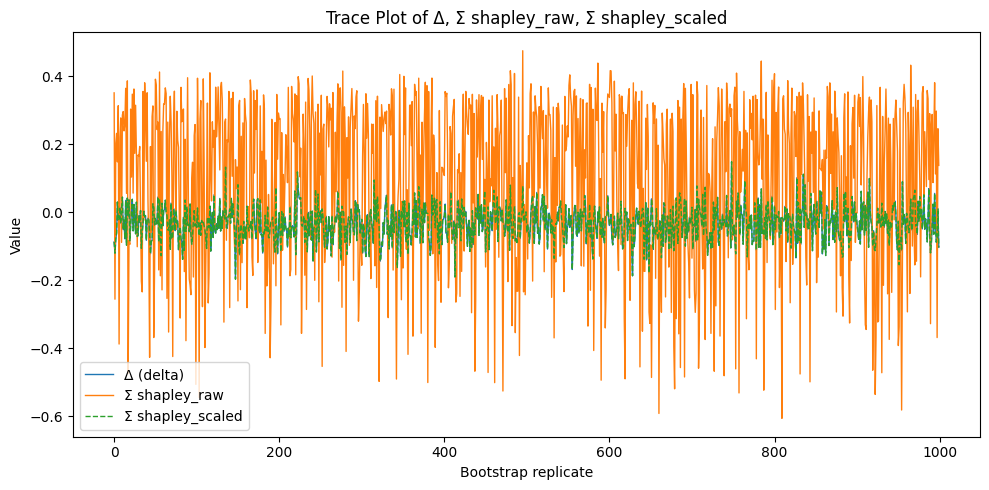

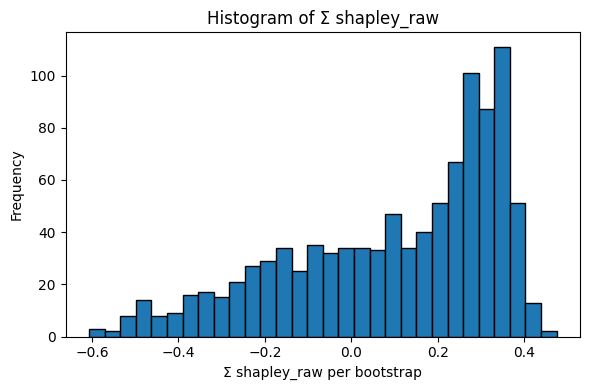

In [ ]:
plot_bootstrap_diagnostics(result_eicu)

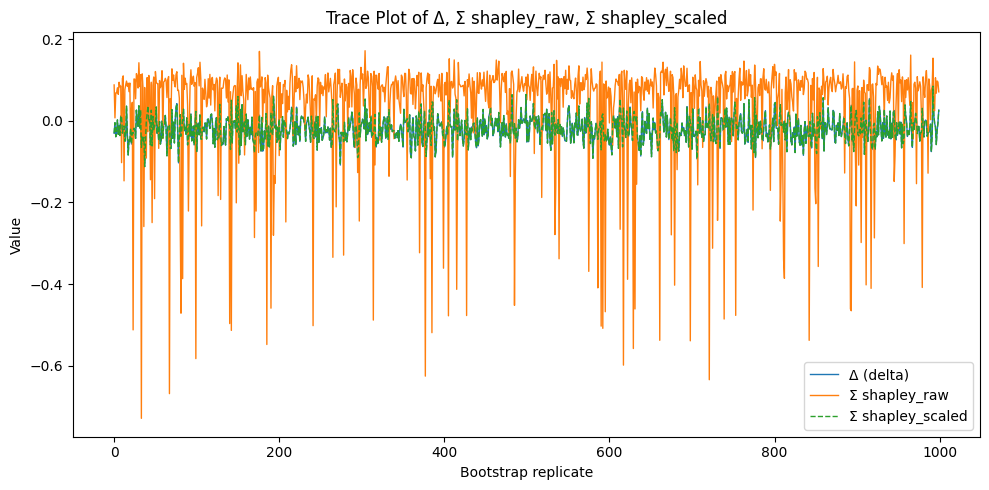

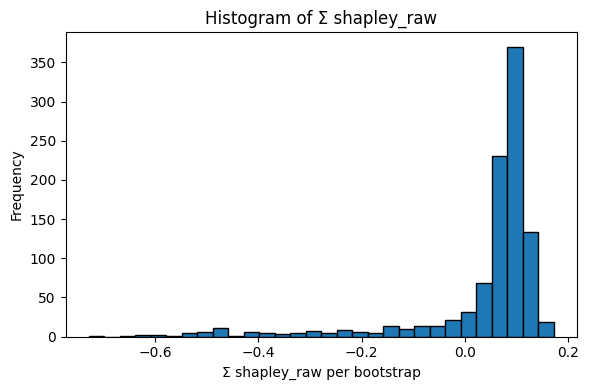

In [ ]:
with open('./analysis_results/results_eicu_cf.pkl', 'rb') as f:
    result_eicu_cf = pickle.load(f)

plot_bootstrap_diagnostics(result_eicu_cf)

In [ ]:
data_type = ['eicu', 'mimic']
task_type = ['cf', 'aki', 'mor', 'los']
result_df = pd.DataFrame()

for i in data_type:
    for j in task_type:
        with open(f'./analysis_results/results_{i}_{j}.pkl', 'rb') as f:
            tmp_df = pickle.load(f)
            delta_all = np.array(tmp_df['delta_summary']['all'])

            # --- raw AUPRC source / target / delta: mean ± 2*SE CI ---
            shapley_raw_summary = tmp_df['shapley_raw_summary'].copy()

            # bootstrap 점수
            bs_source = np.array(tmp_df['bootstrap_source_scores'])
            bs_target = np.array(tmp_df['bootstrap_target_scores'])

            # 표준오차 계산
            se_source = bs_source.std(ddof=1)
            se_target = bs_target.std(ddof=1)
            se_delta  = delta_all.std(ddof=1)

            # 평균
            mean_source = bs_source.mean()
            mean_target = bs_target.mean()
            mean_delta  = delta_all.mean()

            # CI 경계
            lo_src, hi_src = mean_source - 2*se_source, mean_source + 2*se_source
            lo_tgt, hi_tgt = mean_target - 2*se_target, mean_target + 2*se_target
            lo_del, hi_del = mean_delta  - 2*se_delta,  mean_delta  + 2*se_delta

            # summary에 추가
            shapley_raw_summary.loc['auprc_source', ['mean','ci_lower','ci_upper']] = [
                round(mean_source,4), round(lo_src,4), round(hi_src,4)
            ]
            shapley_raw_summary.loc['auprc_target', ['mean','ci_lower','ci_upper']] = [
                round(mean_target,4), round(lo_tgt,4), round(hi_tgt,4)
            ]
            shapley_raw_summary.loc['delta', ['mean','ci_lower','ci_upper']] = [
                round(mean_delta,4), round(lo_del,4), round(hi_del,4)
            ]

            # 문자열 포맷
            shapley_raw_summary['mean'] = (
                shapley_raw_summary['mean'].round(4).astype(str)
                + " ("
                + shapley_raw_summary['ci_lower'].round(4).astype(str)
                + ", "
                + shapley_raw_summary['ci_upper'].round(4).astype(str)
                + ")"
            )
            shapley_raw_summary = shapley_raw_summary.drop(['ci_lower','ci_upper'], axis=1)
            shapley_raw_summary = shapley_raw_summary.add_prefix(f'{i}_{j}_raw_')

            # --- scaled도 동일하게 ---
            shapley_scaled_summary = tmp_df['shapley_scaled_summary'].copy()
            shapley_scaled = tmp_df['shapley_scaled_all']  # (n_bootstrap × n_features) DataFrame

            n_bs = shapley_scaled.shape[0]
            se_feat = shapley_scaled.std(ddof=1)
            mean_feat = shapley_scaled.mean()

            lo_feat = mean_feat - 2*se_feat
            hi_feat = mean_feat + 2*se_feat

            shapley_scaled_summary['mean'] = (
                mean_feat.round(4).astype(str)
                + " ("
                + lo_feat.round(4).astype(str)
                + ", "
                + hi_feat.round(4).astype(str)
                + ")"
            )
            shapley_scaled_summary = shapley_scaled_summary.drop(['ci_lower','ci_upper'], axis=1)
            shapley_scaled_summary = shapley_scaled_summary.add_prefix(f'{i}_{j}_scaled_')

            # concat
            shapley = pd.concat([shapley_raw_summary, shapley_scaled_summary], axis=1)
            result_df = pd.concat([result_df, shapley], axis=1)


result_df.to_csv('./analysis_results/results_aggregated_new_ci.csv')  